C:\Users\adhit\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1 | D Loss: 0.6859 | G Loss: 0.6905
Epoch 2 | D Loss: 0.6901 | G Loss: 0.6803
Epoch 3 | D Loss: 0.6926 | G Loss: 0.6741
Epoch 4 | D Loss: 0.6944 | G Loss: 0.6697
Epoch 5 | D Loss: 0.6956 | G Loss: 0.6661
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


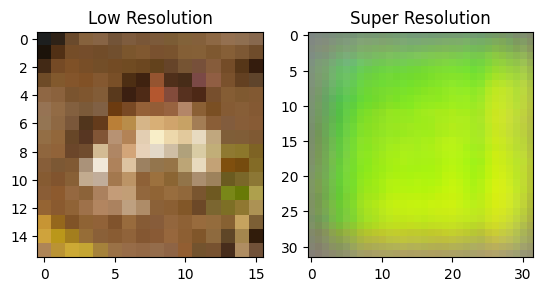

In [2]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load Dataset (CIFAR10)
# -----------------------------
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.0

# Create Low Resolution (LR) images
def downsample(images):
    return tf.image.resize(images, [16, 16])

lr_images = downsample(x_train).numpy()
hr_images = tf.image.resize(lr_images, [32, 32]).numpy()

# -----------------------------
# Generator (SR ResNet style)
# -----------------------------
def residual_block(x):
    res = layers.Conv2D(64, 3, padding='same')(x)
    res = layers.BatchNormalization()(res)
    res = layers.PReLU()(res)
    res = layers.Conv2D(64, 3, padding='same')(res)
    res = layers.BatchNormalization()(res)
    return layers.add([x, res])

def build_generator():
    inputs = layers.Input(shape=(16,16,3))
    x = layers.Conv2D(64, 9, padding='same')(inputs)
    x = layers.PReLU()(x)
    
    skip = x
    
    for _ in range(5):
        x = residual_block(x)
    
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, skip])
    
    # Upsampling
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.PReLU()(x)
    
    outputs = layers.Conv2D(3, 9, padding='same', activation='sigmoid')(x)
    
    return Model(inputs, outputs)

# -----------------------------
# Discriminator
# -----------------------------
def disc_block(x, filters, strides=1):
    x = layers.Conv2D(filters, 3, strides=strides, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    return x

def build_discriminator():
    inputs = layers.Input(shape=(32,32,3))
    
    x = layers.Conv2D(64, 3, padding='same')(inputs)
    x = layers.LeakyReLU(0.2)(x)
    
    x = disc_block(x, 64, 2)
    x = disc_block(x, 128)
    x = disc_block(x, 128, 2)
    x = disc_block(x, 256)
    
    x = layers.Flatten()(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return Model(inputs, outputs)

# -----------------------------
# Build Models
# -----------------------------
generator = build_generator()
discriminator = build_discriminator()

# Compile Discriminator
discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Freeze discriminator for GAN
discriminator.trainable = False

# GAN Model
lr_input = layers.Input(shape=(16,16,3))
fake_hr = generator(lr_input)
validity = discriminator(fake_hr)

gan = Model(lr_input, validity)

gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# -----------------------------
# Training
# -----------------------------
batch_size = 32
epochs = 5

real = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

for epoch in range(epochs):
    idx = np.random.randint(0, lr_images.shape[0], batch_size)
    lr_batch = lr_images[idx]
    hr_batch = hr_images[idx]
    
    fake_hr = generator.predict(lr_batch, verbose=0)
    
    # Train Discriminator
    d_loss_real = discriminator.train_on_batch(hr_batch, real)
    d_loss_fake = discriminator.train_on_batch(fake_hr, fake)
    
    # Train Generator
    g_loss = gan.train_on_batch(lr_batch, real)
    
    print(f"Epoch {epoch+1} | D Loss: {d_loss_real[0]:.4f} | G Loss: {g_loss:.4f}")

# -----------------------------
# Test / Generate Output
# -----------------------------
test_lr = lr_images[0:1]
generated_hr = generator.predict(test_lr)

plt.subplot(1,2,1)
plt.title("Low Resolution")
plt.imshow(test_lr[0])

plt.subplot(1,2,2)
plt.title("Super Resolution")
plt.imshow(generated_hr[0])

plt.show()